In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv(r'/content/heart_disease_knn_dataset-2.csv')
# Display the first few rows
print(data.head())
# Check for missing values
print(data.isnull().sum())
# Handle missing values if necessary
data.fillna(data.mean(), inplace=True)

   Age  Cholesterol  BloodPressure  MaxHeartRate  ExerciseHoursPerWeek  \
0   63          253            113            95                     3   
1   53          184            143           185                     9   
2   39          250            122           183                     4   
3   67          280            113           136                     1   
4   32          150            125           188                    10   

   HeartDisease  
0             1  
1             1  
2             1  
3             1  
4             0  
Age                     0
Cholesterol             0
BloodPressure           0
MaxHeartRate            0
ExerciseHoursPerWeek    0
HeartDisease            0
dtype: int64


In [3]:
data.shape

(120, 6)

In [4]:
# Define features and target
X = data[['Age', 'BloodPressure','MaxHeartRate','ExerciseHoursPerWeek']]
y = data['Cholesterol']   # Continuous target


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
# Find best K
a = -1
k = 0

for i in range(1, 10):
    m = KNeighborsRegressor(n_neighbors=i)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    if r2 > a:
       a = r2
       k = i

print("Best K:", k)

Best K: 5


In [8]:
# Final model
k = 5
model = KNeighborsRegressor(n_neighbors=k)
model.fit(X_train, y_train)


KNeighborsRegressor()

In [9]:
# Prediction
y_pred = model.predict(X_test)

In [10]:
y_pred

array([222.4, 222.2, 199. , 213. , 222. , 238.2, 194.4, 255.8, 213.4,
       235.4, 230.8, 241. , 211.6, 240.8, 246.6, 235.2, 224.8, 246.6,
       243.4, 221.8, 213.6, 239.8, 222.4, 263.6])

In [11]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [12]:
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 2522.33
RMSE: 50.22280358562234
R2 Score: 0.06534154298260908


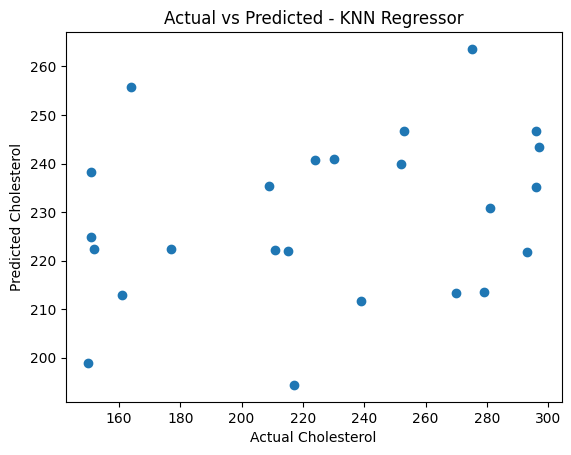

In [13]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Actual vs Predicted - KNN Regressor")
plt.show()

In [14]:
import gradio as gr

In [15]:
# Function for prediction
def predict_cholesterol(age, bp, hr, exercise, k):
    model = KNeighborsRegressor(n_neighbors=int(k))
    model.fit(X_train, y_train)

    input_data = np.array([[age, bp, hr, exercise]])
    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)

    return f"Predicted Cholesterol Level: {prediction[0]:.2f}"

# Gradio Interface
interface = gr.Interface(
    fn=predict_cholesterol,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Max Heart Rate"),
        gr.Number(label="Exercise Hours Per Week"),
        gr.Slider(1, 15, step=1, value=5, label="Select K Value")
    ],
    outputs="text",
    title="KNN Cholesterol Predictor (Regression)",
    description="Enter patient details and select K to predict cholesterol level."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6752d5b1ef46b00796.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
